## Analysis of the reading times

Extracting the duration of the break in between the sentences

In [ ]:
import csv
import pandas as pd

participant_1 = pd.read_csv('/work/Group5/logfile_Participant1_2026-03-24_10h31.04.092.csv')
participant_2 = pd.read_csv('/work/Group5/logfile_Participant2_2026-03-24_10h54.05.032.csv')


condition_names = { # changing the condition names to the ones we are using now, since originally we named them a bit differently
    "congruent": "Congruent",
    "logical": "Related",
    "semantic": "Unrelated"
}

participant_1["Condition"] = participant_1["Condition"].replace(condition_names)
participant_2["Condition"] = participant_2["Condition"].replace(condition_names)

print(participant_1.head())
print(participant_2.head())

data_marker_file_own = data_folder / 'group5_own.vmrk'

data_marker_file_other = data_folder / 'group5_other.vmrk'

marker_1 = mne.read_annotations(data_marker_file_other)
marker_2 = mne.read_annotations(data_marker_file_own)

   Unnamed: 0       ID  Age  Gender  Sentence_Number Shown_Word  Reading_time  \
0           0  Melanie   23  Female                1         He      0.837384   
1           1  Melanie   23  Female                1     wanted      0.484605   
2           2  Melanie   23  Female                1         to      0.495372   
3           3  Melanie   23  Female                1       hear      0.493585   
4           4  Melanie   23  Female                1        the      0.407284   

  Condition  Count  Trigger  
0   Related     13      201  
1   Related     14      202  
2   Related     15      203  
3   Related     16      204  
4   Related     17      205  
   Unnamed: 0      ID  Age Gender  Sentence_Number Shown_Word  Reading_time  \
0           0  Marius   22   Male                1         He      0.888715   
1           1  Marius   22   Male                1    carried      0.523180   
2           2  Marius   22   Male                1        his      0.530191   
3           3  Ma

In [31]:

onset_data_1 = pd.DataFrame({
    "onset": marker_1.onset,
    "trigger": marker_1.description
})

onset_data_2 = pd.DataFrame({
    "onset": marker_2.onset,
    "trigger": marker_2.description
})

print(onset_data_1.head())
print(onset_data_2.head())

    onset        trigger
0  71.088  Stimulus/S201
1  71.937  Stimulus/S202
2  72.430  Stimulus/S203
3  72.936  Stimulus/S204
4  73.438  Stimulus/S205
    onset        trigger
0  95.168  Stimulus/S 45
1  96.075  Stimulus/S 46
2  96.609  Stimulus/S 47
3  97.154  Stimulus/S 48
4  97.739  Stimulus/S 49


Combining the behavioral data with the onsets of the stimulus

In [32]:
# checking whether the length of the data frames is the same to ensure that they can be combined and no values are missing
print(len(participant_1))
print(len(onset_data_1))

print(len(participant_2))
print(len(onset_data_2))


1038
1038
1038
1038


In [33]:
participant_1["onset"] = onset_data_1["onset"].values
print(participant_1.head())

participant_2["onset"] = onset_data_2["onset"].values
print(participant_2.head())

   Unnamed: 0       ID  Age  Gender  Sentence_Number Shown_Word  Reading_time  \
0           0  Melanie   23  Female                1         He      0.837384   
1           1  Melanie   23  Female                1     wanted      0.484605   
2           2  Melanie   23  Female                1         to      0.495372   
3           3  Melanie   23  Female                1       hear      0.493585   
4           4  Melanie   23  Female                1        the      0.407284   

  Condition  Count  Trigger   onset  
0   Related     13      201  71.088  
1   Related     14      202  71.937  
2   Related     15      203  72.430  
3   Related     16      204  72.936  
4   Related     17      205  73.438  
   Unnamed: 0      ID  Age Gender  Sentence_Number Shown_Word  Reading_time  \
0           0  Marius   22   Male                1         He      0.888715   
1           1  Marius   22   Male                1    carried      0.523180   
2           2  Marius   22   Male               

In [34]:
# Making a loop that calculates the break duration in seconds 
# after every sentence except the last one, since it doesn't have a sentece after it

breaks_1 = []

breaks_1_dictionary = {
    "Congruent": [],
    "Related": [],
    "Unrelated": []
}

for sentence in range(1, 90):

    last_word_row = participant_1[participant_1["Sentence_Number"] == sentence].iloc[-1]
    next_first_row = participant_1[participant_1["Sentence_Number"] == sentence + 1].iloc[0]

    last_onset = last_word_row["onset"]
    next_onset = next_first_row["onset"]

    last_word = last_word_row["Shown_Word"]
    break_duration = next_onset - last_onset - last_word_row["Reading_time"]
    condition = last_word_row["Condition"]
    reading_time = last_word_row["Reading_time"]
    word_lenght = len(last_word_row["Shown_Word"])
    
    breaks_1.append([last_word, break_duration, condition, reading_time, word_lenght])
    breaks_1_dictionary[condition].append(break_duration)


breaks_2 = []

breaks_2_dictionary = {
    "Congruent": [],
    "Related": [],
    "Unrelated": []
}

for sentence in range(1, 90):

    last_word_row = participant_2[participant_2["Sentence_Number"] == sentence].iloc[-1]
    next_first_row = participant_2[participant_2["Sentence_Number"] == sentence + 1].iloc[0]

    last_onset = last_word_row["onset"]
    next_onset = next_first_row["onset"]

    last_word = last_word_row["Shown_Word"]
    break_duration = next_onset - last_onset - last_word_row["Reading_time"]
    condition = last_word_row["Condition"]
    reading_time = last_word_row["Reading_time"]
    word_length = len(last_word_row["Shown_Word"])
    
    breaks_2.append([last_word, break_duration, condition, reading_time, word_lenght])
    breaks_2_dictionary[condition].append(break_duration)

# Changing break_1 and break_2 to data frames

breaks_1 = pd.DataFrame(breaks_1, columns=["Shown_Word", "Break_Duration", "Condition", "Reading_Time", "Word_Length"])
breaks_2 = pd.DataFrame(breaks_2, columns=["Shown_Word", "Break_Duration", "Condition", "Reading_Time", "Word_Length"])

print(breaks_1.head())
print(breaks_2.head())

print(breaks_1_dictionary)
print(breaks_2_dictionary)

  Shown_Word  Break_Duration  Condition  Reading_Time  Word_Length
0        off        1.481425    Related      0.479575            3
1     income        0.844117  Unrelated      0.446883            6
2       weak        0.560298    Related      0.470702            4
3       read        0.634542    Related      0.455458            4
4     school        0.535884    Related      0.511116            6
  Shown_Word  Break_Duration  Condition  Reading_Time  Word_Length
0       sing        2.617378  Unrelated      0.918622            6
1  interview        2.696420  Unrelated      0.422580            6
2       disc        3.859896  Unrelated      0.503104            6
3      salad        2.743344  Unrelated      0.455656            6
4       safe        2.922675  Congruent      0.422325            6
{'Congruent': [np.float64(0.5293307999074415), np.float64(0.5700692999810002), np.float64(0.48635270088911403), np.float64(0.4593884986340982), np.float64(0.5763784998357266), np.float64(0.5357964

Boxplots

Text(0.5, 1.0, 'Break Durations by Condition (Participant 1)')

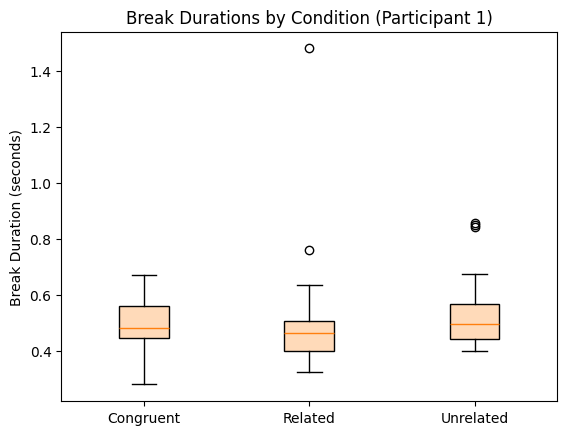

In [35]:
# boxplots

boxplot_1 = plt.boxplot([breaks_1_dictionary["Congruent"],breaks_1_dictionary["Related"], breaks_1_dictionary["Unrelated"]],
    tick_labels = breaks_1_dictionary.keys(), patch_artist=True)

for patch in boxplot_1['boxes']:
    patch.set_facecolor("peachpuff")

plt.ylabel("Break Duration (seconds)")
plt.title("Break Durations by Condition (Participant 1)")


Text(0.5, 1.0, 'Break Durations by Condition (Participant 2)')

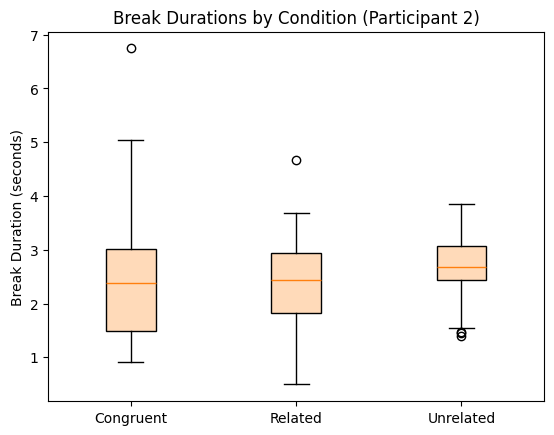

In [36]:
boxplot_2 = plt.boxplot([breaks_2_dictionary["Congruent"],breaks_2_dictionary["Related"], breaks_2_dictionary["Unrelated"]],
    tick_labels = breaks_2_dictionary.keys(), patch_artist=True)


for patch in boxplot_2['boxes']:
    patch.set_facecolor("peachpuff")

plt.ylabel("Break Duration (seconds)")
plt.title("Break Durations by Condition (Participant 2)")

Analysis

In [37]:
# Summaries

summary_list_1 = []

for condition in breaks_1_dictionary.keys():
    values = breaks_1_dictionary[condition]
    stats = {
        'Condition': condition,
        'Mean (s)': np.mean(values),
        'Median (s)': np.median(values),
        'SD (s)': np.std(values),
        'N_trials': len(values)
    }
    summary_list_1.append(stats)

summary_1 = pd.DataFrame(summary_list_1, columns=["Condition", "Mean (s)", "Median (s)", "SD (s)", "N_trials"])
print("Summary for Participant 1")
print(summary_1)

summary_list_2 = []

for condition in breaks_2_dictionary.keys():
    values = breaks_2_dictionary[condition]
    stats = {
        'Condition': condition,
        'Mean (s)': np.mean(values),
        'Median (s)': np.median(values),
        'SD (s)': np.std(values),
        'N_trials': len(values)
    }
    summary_list_2.append(stats)

summary_2 = pd.DataFrame(summary_list_2, columns=["Condition", "Mean (s)", "Median (s)", "SD (s)", "N_trials"])
print("Summary for Participant 2")
print(summary_2)

Summary for Participant 1
   Condition  Mean (s)  Median (s)    SD (s)  N_trials
0  Congruent  0.498053    0.482208  0.092454        30
1    Related  0.496826    0.464328  0.205537        29
2  Unrelated  0.533857    0.494988  0.124932        30
Summary for Participant 2
   Condition  Mean (s)  Median (s)    SD (s)  N_trials
0  Congruent  2.481098    2.388052  1.286295        30
1    Related  2.420959    2.428064  0.960628        30
2  Unrelated  2.621086    2.677115  0.630701        29


## Description of the stimuli

In [38]:
# Calculating sentence and critical word lengths

sentences_length = []

sent_len_by_condition = {
    "Congruent": [],
    "Related": [],
    "Unrelated": []
}

critical_words_lengths = []

crit_words_by_condition  = {
    "Congruent": [],
    "Related": [],
    "Unrelated": []
}

for sentence in range(1, 91):

    first_word_row = participant_1[participant_1["Sentence_Number"] == sentence].iloc[0]
    last_word_row = participant_1[participant_1["Sentence_Number"] == sentence].iloc[-1]

    first_count = first_word_row["Count"]
    last_count = last_word_row["Count"]
    critical_word = str(last_word_row["Shown_Word"])
    critical_word_length = len(critical_word)

    sentence_length = last_count - first_count + 1
    condition = last_word_row["Condition"]

    sentences_length.append(sentence_length)
    sent_len_by_condition[condition].append(sentence_length)
    critical_words_lengths.append(critical_word_length)
    crit_words_by_condition[condition].append(critical_word_length)


## sentences

print(f"Mean Sentence Length: {np.mean(sentences_length):.2f} words")
print(f"Standard Deviation: {np.std(sentences_length):.2f} words")
print(f"Range: {np.min(sentences_length)} - {np.max(sentences_length)} words")

summary_list_sentences = []

for condition in sent_len_by_condition.keys():
    values = sent_len_by_condition[condition]
    stats = {
        'Condition': condition,
        'Mean length (words)': round(np.mean(values), 2),
        'SD (words)': round(np.std(values), 2),
        'Range (words)': f"{np.min(values)} - {np.max(values)}"
    }
    summary_list_sentences.append(stats)

summary_sentences = pd.DataFrame(summary_list_sentences, columns=["Condition", "Mean length (words)", "SD (words)", "Range (words)"])
print("Summary of the sentences by condition")
print(summary_sentences)


## critical words

print(f"Mean Critical Word Length: {np.mean(critical_words_lengths):.2f} characters")
print(f"Standard Deviation: {np.std(critical_words_lengths):.2f} characters")
print(f"Range: {np.min(critical_words_lengths)} - {np.max(critical_words_lengths)} characters")

summary_list_critical_words = []

for condition in crit_words_by_condition.keys():
    values = crit_words_by_condition[condition]
    stats = {
        'Condition': condition,
        'Mean length (characters)': round(np.mean(values), 2),
        'SD (characters)': round(np.std(values), 2),
        'Range (characters)': f"{np.min(values)} - {np.max(values)}"
    }
    summary_list_critical_words.append(stats)

summary_critical_words = pd.DataFrame(summary_list_critical_words, columns=["Condition", "Mean length (characters)", "SD (characters)", "Range (characters)"])
print("Summary of the critical words by condition")
print(summary_critical_words)

Mean Sentence Length: 11.53 words
Standard Deviation: 1.94 words
Range: 8 - 17 words
Summary of the sentences by condition
   Condition  Mean length (words)  SD (words) Range (words)
0  Congruent                11.33        1.72        8 - 15
1    Related                11.30        2.07        8 - 16
2  Unrelated                11.97        1.96        9 - 17
Mean Critical Word Length: 5.33 characters
Standard Deviation: 1.84 characters
Range: 2 - 13 characters
Summary of the critical words by condition
   Condition  Mean length (characters)  SD (characters) Range (characters)
0  Congruent                       5.3             1.72              2 - 9
1    Related                       4.8             1.92             3 - 13
2  Unrelated                       5.9             1.72              4 - 9


#### Break Time Model

Defining functions

In [63]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

def assumption_test_ols(model):
    fitted = model.fittedvalues
    residuals = model.resid

    plt.scatter(fitted, residuals)
    plt.axhline(0, linestyle='--')
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.show()

    sm.qqplot(residuals, line='45')
    plt.show()

def assumption_test_gamma(model, df):
    fitted = model.fittedvalues

    plt.figure()
    plt.scatter(fitted, df["Reading_Time"], alpha=0.5)
    plt.plot([fitted.min(), fitted.max()],
            [fitted.min(), fitted.max()],
            linestyle="--")
    plt.xlabel("Fitted values")
    plt.ylabel("Observed values")
    plt.title("Gamma GLM: Fitted vs Observed")
    plt.show()

    stats.probplot(model.resid_deviance, dist="norm", plot=plt)
    plt.title("QQ plot of deviance residuals")
    plt.show()

def plot_break(df):
    # Compute means and confidence intervals
    summary = df.groupby("Condition")["log_break"].agg(["mean", "sem"]).reset_index()
    summary["ci"] = 1.96 * summary["sem"]

    # Plot
    plt.figure()
    plt.bar(summary["Condition"], summary["mean"], yerr=summary["ci"])
    plt.xlabel("Condition")
    plt.ylabel("Log Break Duration")
    plt.title("Mean Log Break Duration by Condition")
    plt.show()

def plot_break2(df):
    plt.figure()
    df.boxplot(column="log_break", by="Condition")
    plt.title("Log Break Duration by Condition")
    plt.suptitle("")  # removes default pandas title
    plt.xlabel("Condition")
    plt.ylabel("Log Break Duration")
    plt.show()

def plot_reading(df):
        # Compute means and confidence intervals
    summary = df.groupby("Condition")["log_reading_time"].agg(["mean", "sem"]).reset_index()
    summary["ci"] = 1.96 * summary["sem"]

    # Plot
    plt.figure()
    plt.bar(summary["Condition"], summary["mean"], yerr=summary["ci"])
    plt.xlabel("Condition")
    plt.ylabel("Log Reading Time")
    plt.title("Mean Log Reading Time by Condition")
    plt.show()

def plot_reading2(df):
    plt.figure()
    df.boxplot(column="log_reading_time", by="Condition")
    plt.title("Log Reading Time by Condition")
    plt.suptitle("")  # removes default pandas title
    plt.xlabel("Condition")
    plt.ylabel("Log Reading Time by Condition")
    plt.show()

def inspect_gamma(df):
    y = df["Reading_Time"].dropna()

    # Fit gamma distribution (shape, loc, scale)
    shape, loc, scale = gamma.fit(y, floc=0)  # force positive support

    x = np.linspace(y.min(), y.max(), 200)
    pdf = gamma.pdf(x, shape, loc=loc, scale=scale)

    plt.figure()
    plt.hist(y, bins=30, density=True, alpha=0.5)
    plt.plot(x, pdf, linewidth=2)
    plt.title("Gamma fit check: Reading Time")
    plt.xlabel("Reading Time")
    plt.ylabel("Density")
    plt.show()

def plot_gamma_glm_results(model, df, condition_col="Condition", length_col="Word_Length"):
    """
    Plot results of a Gamma GLM with log link.

    Parameters
    ----------
    model : fitted statsmodels GLMResults
    df : pandas DataFrame used for fitting
    condition_col : str
    length_col : str
    """

    # --- Predictions ---
    df = df.copy()
    df["predicted"] = model.predict(df)

    # --- 1. Observed vs Predicted ---
    plt.figure()
    plt.scatter(df["predicted"], df["Reading_Time"], alpha=0.5)
    plt.xlabel("Predicted Reading Time")
    plt.ylabel("Observed Reading Time")
    plt.title("Observed vs Predicted")
    
    # Diagonal reference line
    min_val = min(df["predicted"].min(), df["Reading_Time"].min())
    max_val = max(df["predicted"].max(), df["Reading_Time"].max())
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.show()

    # --- 2. Effect of Word Length (holding Condition fixed) ---
    plt.figure()
    conditions = df[condition_col].unique()
    x_vals = np.linspace(df[length_col].min(), df[length_col].max(), 100)

    for cond in conditions:
        temp_df = pd.DataFrame({
            condition_col: [cond] * len(x_vals),
            length_col: x_vals
        })
        y_pred = model.predict(temp_df)
        plt.plot(x_vals, y_pred, label=f"{cond}")

    plt.xlabel("Word Length")
    plt.ylabel("Predicted Reading Time")
    plt.title("Effect of Word Length by Condition")
    plt.legend()
    plt.show()

    # --- 3. Boxplot: Predictions by Condition ---
    plt.figure()
    df.boxplot(column="predicted", by=condition_col)
    plt.title("Predicted Reading Time by Condition")
    plt.suptitle("")
    plt.xlabel("Condition")
    plt.ylabel("Predicted Reading Time")
    plt.show()


Participant 1 - Breaks

                            OLS Regression Results                            
Dep. Variable:              log_break   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     1.345
Date:                Mon, 08 Jun 2026   Prob (F-statistic):              0.266
Time:                        10:26:24   Log-Likelihood:                 4.8496
No. Observations:                  89   AIC:                            -3.699
Df Residuals:                      86   BIC:                             3.767
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

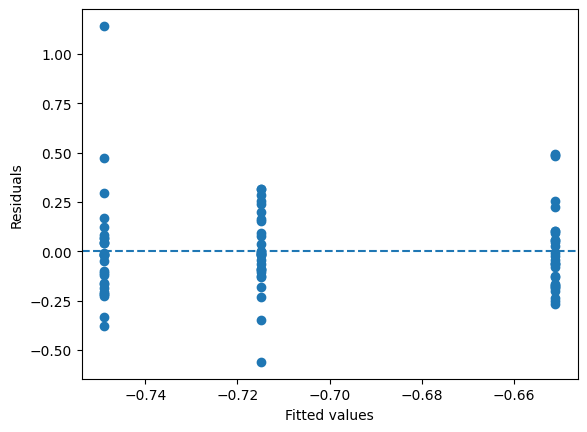

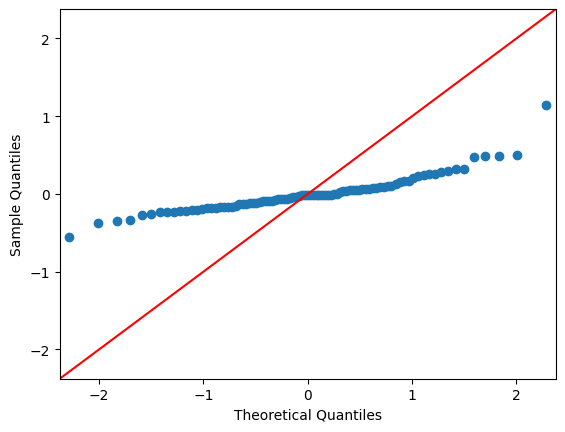

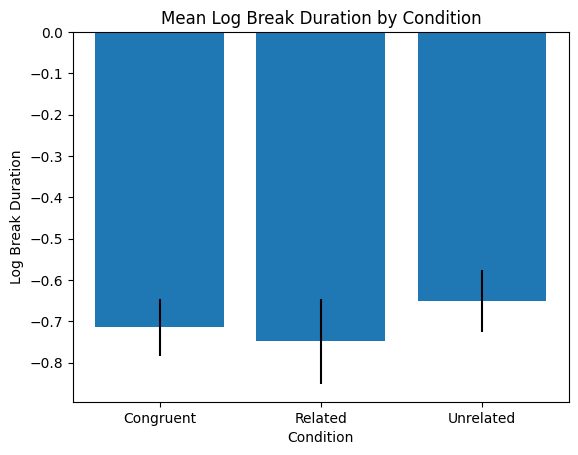

<Figure size 640x480 with 0 Axes>

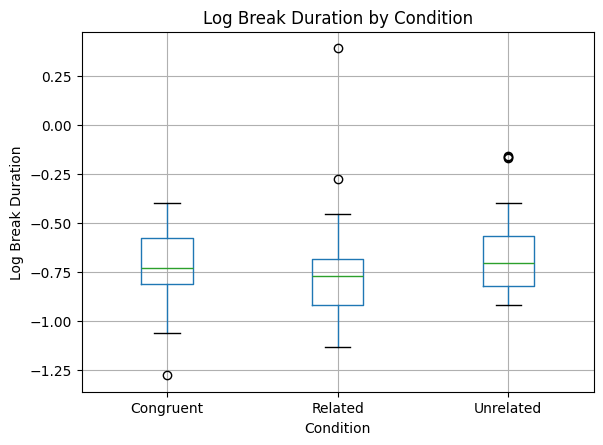

Shown_Word             str
Break_Duration     float64
Condition         category
Reading_Time       float64
Word_Length          int64
log_break          float64
dtype: object


In [64]:
df = breaks_1
df["log_break"] = np.log(df["Break_Duration"])
df["Condition"] = df["Condition"].astype("category")

model = smf.ols("log_break ~ Condition", data=df).fit()
print(model.summary())


assumption_test_ols(model)
plot_break(df)
plot_break2(df)
print(df.dtypes)

Participant 2 - Breaks

Shown_Word             str
Break_Duration     float64
Condition         category
Reading_Time       float64
Word_Length          int64
log_break          float64
dtype: object
                            OLS Regression Results                            
Dep. Variable:              log_break   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.066
Date:                Mon, 08 Jun 2026   Prob (F-statistic):              0.349
Time:                        10:26:24   Log-Likelihood:                -55.137
No. Observations:                  89   AIC:                             116.3
Df Residuals:                      86   BIC:                             123.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef 

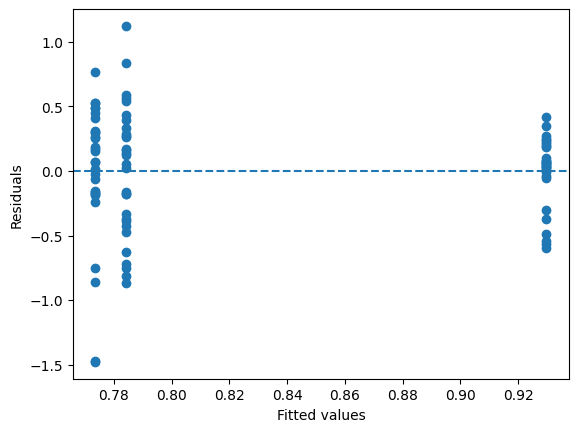

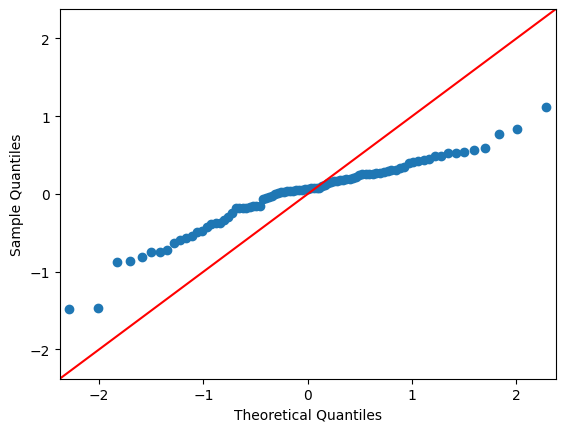

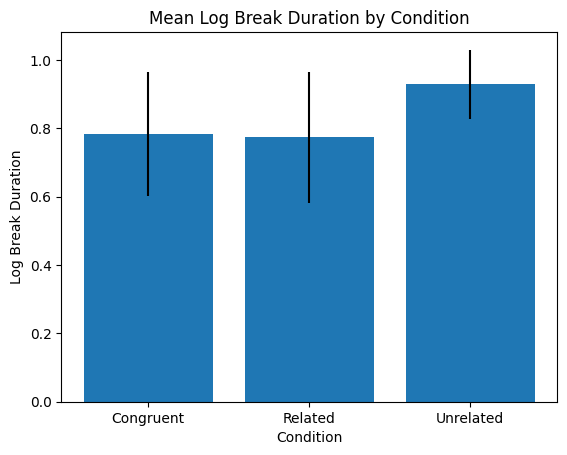

<Figure size 640x480 with 0 Axes>

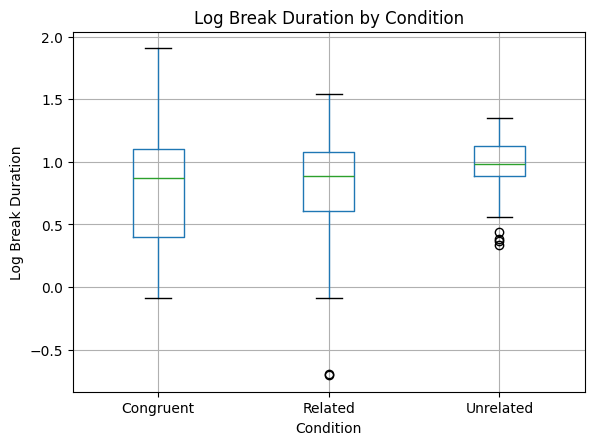

In [65]:
df = breaks_2
df["log_break"] = np.log(df["Break_Duration"])
df["Condition"] = df["Condition"].astype("category")


print(df.dtypes)
model = smf.ols("log_break ~ Condition", data=df).fit()
print(model.summary())

assumption_test_ols(model)

plot_break(df)
plot_break2(df)

#### Reading Time Model

##### Participant 1

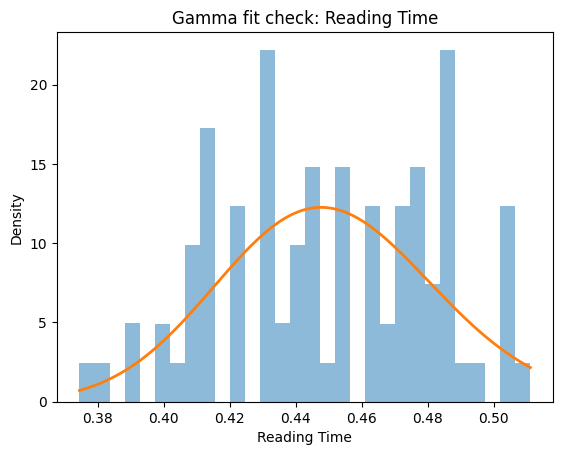

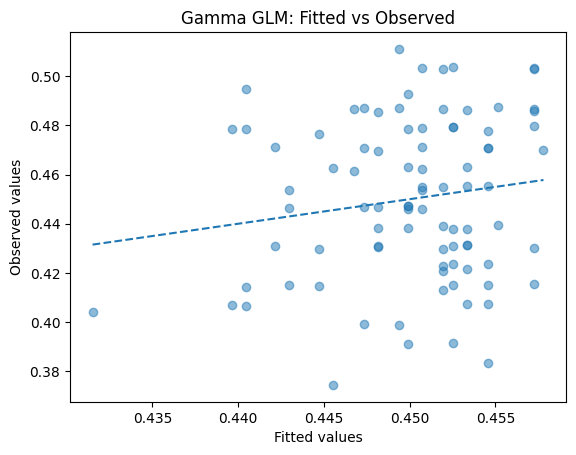

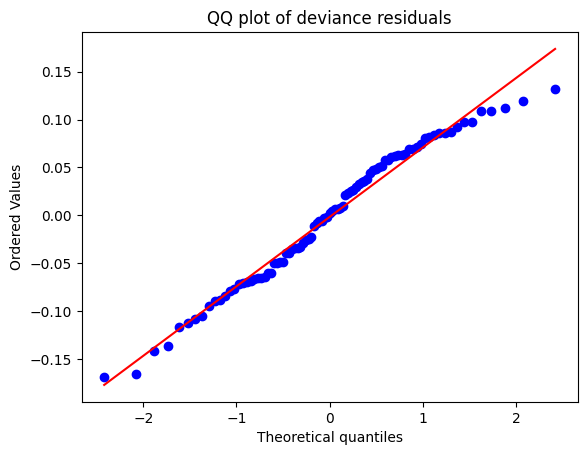

                 Generalized Linear Model Regression Results                  
Dep. Variable:           Reading_Time   No. Observations:                   89
Model:                            GLM   Df Residuals:                       85
Model Family:                   Gamma   Df Model:                            3
Link Function:                    Log   Scale:                       0.0053105
Method:                          IRLS   Log-Likelihood:                 179.53
Date:                Mon, 08 Jun 2026   Deviance:                      0.45703
Time:                        10:26:25   Pearson chi2:                    0.451
No. Iterations:                     6   Pseudo R-squ. (CS):            0.02292
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

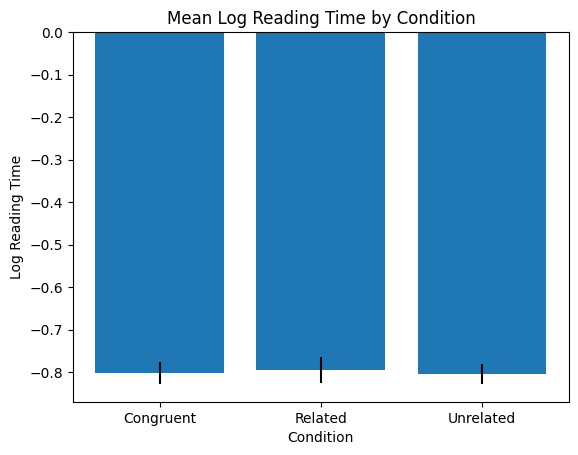

<Figure size 640x480 with 0 Axes>

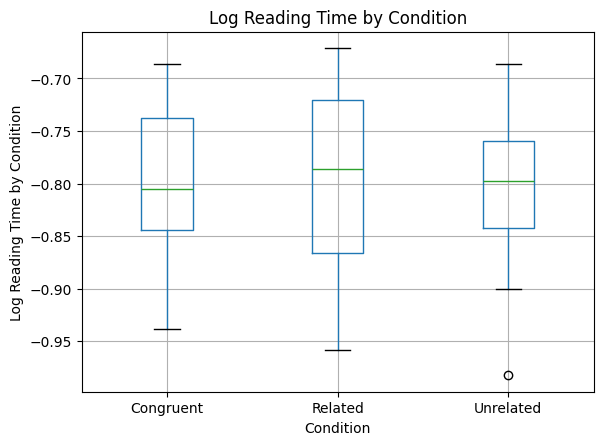

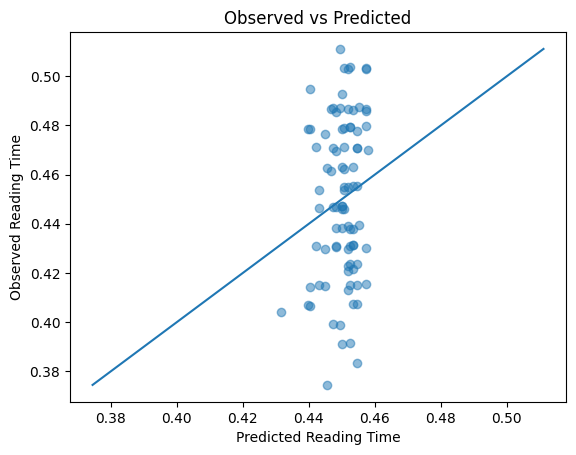

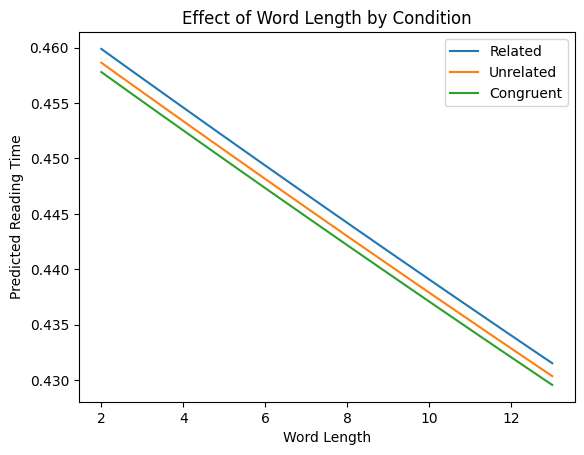

<Figure size 640x480 with 0 Axes>

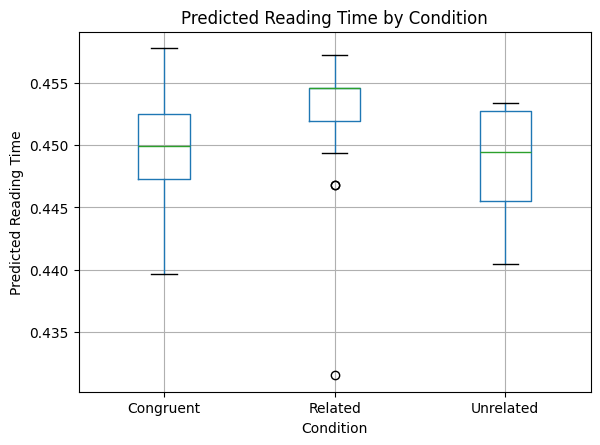

Shown_Word               str
Break_Duration       float64
Condition           category
Reading_Time         float64
Word_Length            int64
log_break            float64
log_reading_time     float64
dtype: object


In [66]:
# Load data
df = breaks_1.copy()
df["log_reading_time"] = np.log(df["Reading_Time"])
df["Condition"] = df["Condition"].astype("category")
df["Word_Length"] = df["Word_Length"]

# Inspect data for Gamma distribution
inspect_gamma(df)

gamma_model = smf.glm(
    "Reading_Time ~ Condition + Word_Length",
    data=df,
    family=sm.families.Gamma(sm.families.links.Log())
).fit()

assumption_test_gamma(gamma_model, df)

print(gamma_model.summary())

plot_reading(df)
plot_reading2(df)
plot_gamma_glm_results(gamma_model, df, condition_col="Condition", length_col="Word_Length")
print(df.dtypes)

##### Participant 2

Shown_Word               str
Break_Duration       float64
Condition           category
Reading_Time         float64
Word_Length            int64
log_break            float64
log_reading_time     float64
dtype: object


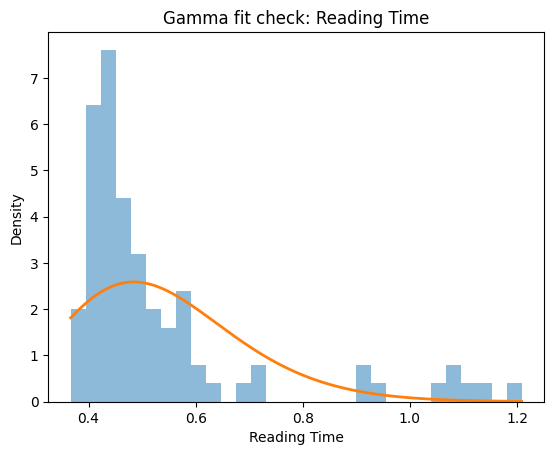

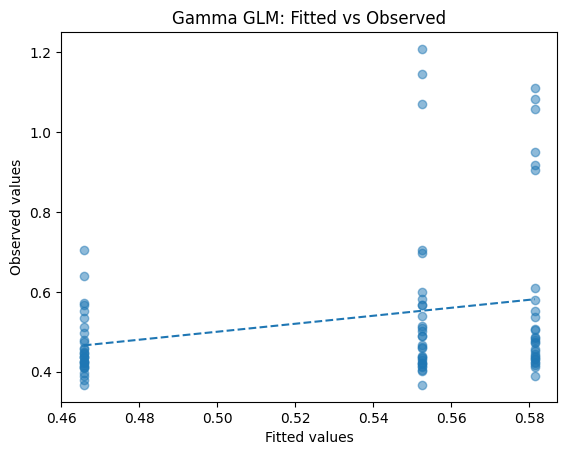

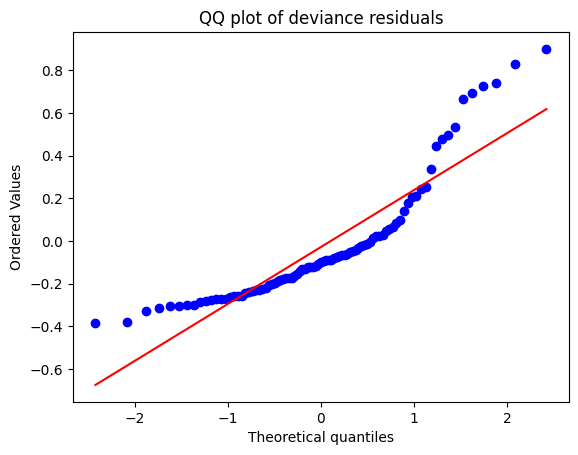

                 Generalized Linear Model Regression Results                  
Dep. Variable:           Reading_Time   No. Observations:                   89
Model:                            GLM   Df Residuals:                       86
Model Family:                   Gamma   Df Model:                            2
Link Function:                    Log   Scale:                         0.11151
Method:                          IRLS   Log-Likelihood:                 42.008
Date:                Mon, 08 Jun 2026   Deviance:                       7.3933
Time:                        10:29:06   Pearson chi2:                     9.59
No. Iterations:                     6   Pseudo R-squ. (CS):            0.07617
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

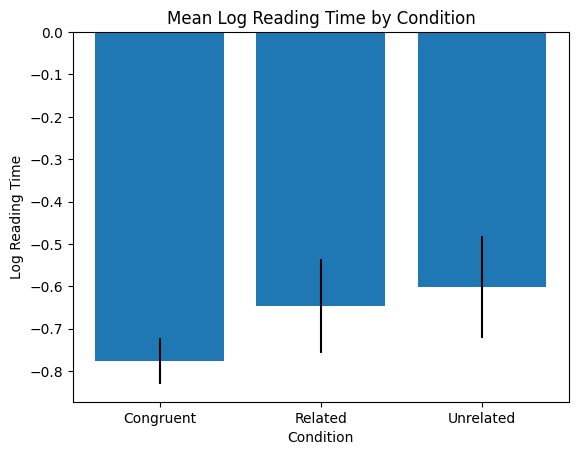

<Figure size 640x480 with 0 Axes>

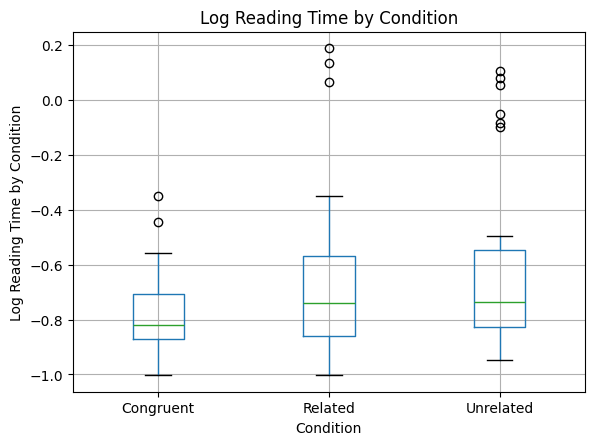

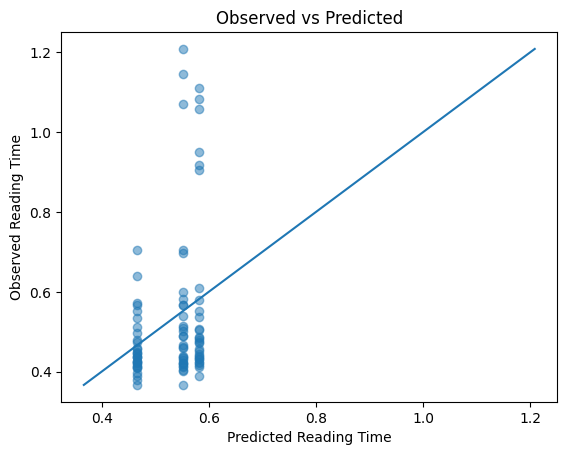

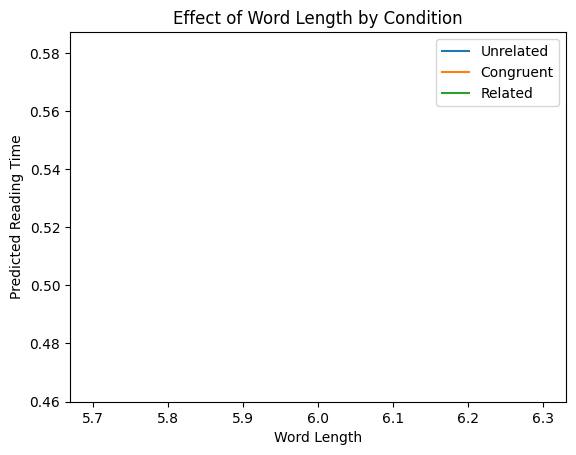

<Figure size 640x480 with 0 Axes>

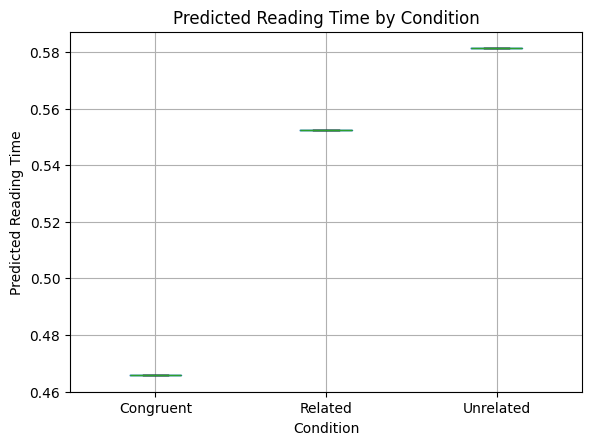

In [68]:
# log(reading_time) <- word_length test
print(df.dtypes)

df = breaks_2.copy()
df = df[
    (df['Reading_Time'] > 0.1) &   # too fast = misfire/anticipation
    (df['Reading_Time'] < 3)    # too slow = mind wandering, distraction
]
df["log_reading_time"] = np.log(df["Reading_Time"])
df["Condition"] = df["Condition"].astype("category")


# Inspect data for Gamma distribution
inspect_gamma(df)

gamma_model = smf.glm(
    "Reading_Time ~ Condition + Word_Length",
    data=df,
    family=sm.families.Gamma(sm.families.links.Log())
).fit()

assumption_test_gamma(gamma_model, df)

print(gamma_model.summary())

plot_reading(df)
plot_reading2(df)
plot_gamma_glm_results(gamma_model, df, condition_col="Condition", length_col="Word_Length")

Citing packages

In [69]:
import matplotlib
import scipy

print(f"MNE: {mne.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Scipy: {scipy.__version__}")
print(f"Csv: {csv.__version__}")
print(f"Pandas: {pd.__version__}")

MNE: 1.11.0
Numpy: 2.4.3
Matplotlib: 3.10.0
Scipy: 1.17.1
Csv: 1.0
Pandas: 3.0.1
